In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',size=18)
import numpy as np
np.set_printoptions(precision=4,linewidth=100)

In [2]:
from pynitride.paramdb import nm,cm, k, hbar, m_e
from pynitride.mesh import Mesh, UniformLayer, MidFunction, PointFunction
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.material import AlGaN
pi=np.pi

In [3]:
import warnings
warnings.filterwarnings('error')
warnings.filterwarnings('default')

In [4]:
dz=.01
m=Mesh([UniformLayer("well",5-dz)],matsys=AlGaN(),max_dz=dz)

In [5]:
from scipy.sparse import diags

In [1]:
Equilibrium(m)
PoissonSolver(m).solve()
m.EvOffset
m.Ev
m['EvOffset']=0
m['Ev']=.00000001
mbkp=MultibandKP(m,ktmax=.5)
Cmats=m._matsys.kp_Cmats(m,kx=mbkp._kt,ky=0*mbkp._kt)
for H,Cmatsk in zip(mbkp._H,Cmats):
    #pass
    
    H[:6,:6]+=Cmatsk[3][:,:,0]/m._dzp[0]/m._dzm[0]
    H[-6:,-6:]+=Cmatsk[3][:,:,-1]/m._dzp[-1]/m._dzm[-1]
    H[:6,-6:]=H[6:12,:6]
    H[-6:,:6]=H[:6,6:12]
mbkp.solve()

0.01133695897795344

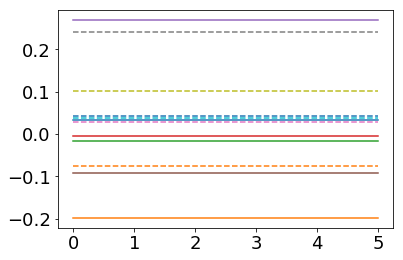

In [7]:
plt.figure()
kti=14
e=0
plt.plot(m.zp,np.real(m.kppsi[kti,e,0,:])) #big
plt.plot(m.zp,np.real(m.kppsi[kti,e,1,:])) #big
plt.plot(m.zp,np.real(m.kppsi[kti,e,2,:])) #nothing
plt.plot(m.zp,np.real(m.kppsi[kti,e,3,:])) #smaller
plt.plot(m.zp,np.real(m.kppsi[kti,e,4,:])) #smaller
plt.plot(m.zp,np.real(m.kppsi[kti,e,5,:])) #nothing
plt.plot(m.zp,np.imag(m.kppsi[kti,e,0,:]),'--') #big
plt.plot(m.zp,np.imag(m.kppsi[kti,e,1,:]),'--') #big
plt.plot(m.zp,np.imag(m.kppsi[kti,e,2,:]),'--') #nothing
plt.plot(m.zp,np.imag(m.kppsi[kti,e,3,:]),'--') #smaller
plt.plot(m.zp,np.imag(m.kppsi[kti,e,4,:]),'--') #smaller
plt.plot(m.zp,np.imag(m.kppsi[kti,e,5,:]),'--') #nothing
m.kpen[kti,e,100]

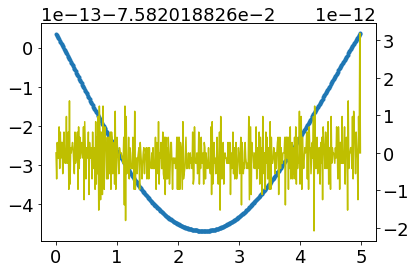

In [8]:
c=5
plt.plot(m.zp,np.imag(m.kppsi[kti,e,c,:]),'.') #big
#plt.xlim(-.05,.05)
#plt.ylim(0,.05)
plt.twinx()
plt.plot(m.zp,-np.imag((m.kppsi[kti,e,c,:]).differentiate().differentiate()),'y') #big

In [9]:
m.kppsi[kti,e,0,:].differentiate().differentiate()/m.kppsi[kti,e,0,:]

Function([         nan        +nanj,  -3.9722e-11 +4.3986e-11j,  -3.6985e-11 +2.7368e-11j,
        -3.4964e-11 -5.0788e-12j,  -3.6410e-11 +3.3052e-11j,  -2.7699e-11 +1.2537e-12j,
        -1.7200e-11 +2.6472e-11j,  -2.7986e-11 -1.5881e-12j,  -5.4830e-11 +4.3084e-11j,
        -1.0506e-11 +9.6745e-12j,  -1.4605e-11 -2.9057e-13j,  -5.2167e-11 +3.8840e-11j,
        -3.3082e-12 -6.5116e-12j,  -3.8353e-11 +3.5677e-11j,  -2.2231e-11 +2.9095e-12j,
        -3.0581e-11 +2.5175e-11j,  -3.6981e-11 +9.9213e-12j,  -1.9717e-11 +2.3414e-11j,
        -1.9572e-11 +1.6112e-11j,  -4.0651e-11 +1.2942e-11j,   4.1699e-12 +1.5037e-11j,
        -5.2955e-11 +1.7940e-11j,  -2.0508e-11 +1.9961e-11j,  -1.6980e-11 +6.7955e-12j,
        -4.9143e-11 +2.5063e-11j,   2.4465e-12 -2.0140e-12j,  -2.4178e-11 +2.2982e-11j,
        -3.7343e-11 +1.9454e-11j,  -3.0365e-11 +2.2945e-11j,  -1.8274e-11 +2.7304e-12j,
        -2.3816e-11 +1.3449e-11j,  -1.8062e-11 +1.7947e-11j,  -3.1875e-11 +2.1110e-11j,
        -1.7771e-11 +3.3420e-

In [10]:
(2*pi/(5))**2

1.5791367041742972

In [11]:
m.kpen[0,4,100]

-0.0061349296038504765

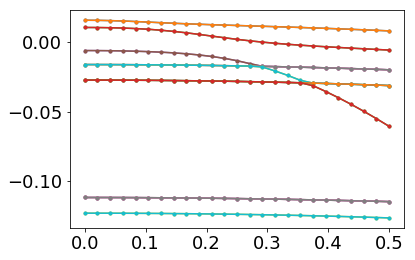

In [13]:
plt.plot(mbkp._kt,m.kpen[:,:,0]-m.Ev[0],'.-');
#plt.ylim(-.1,.05)

In [39]:
trial=np.zeros([6*m.Np],dtype='complex')
trial[0::6]=np.exp(1j*2*pi/(10+4*dz)*(m.zp+dz))-np.exp(-1j*2*pi/(10+4*dz)*(m.zp+dz))+.000001

In [40]:
trial[::6][-1]

(9.9999999999999995e-07+0.012516223693859739j)

In [41]:
2*np.pi/5

1.2566370614359172

In [42]:
np.atleast_2d(trial).shape

(1, 3006)

In [43]:
from scipy.sparse import lil_matrix

In [44]:
np.reshape(np.array([[1,2,3],[4,5,6]]).T,6)

array([1, 4, 2, 5, 3, 6])

In [45]:
tt=np.reshape(m.kppsi[0,0,:,:].T,6*m.Np)

In [46]:
(np.ravel(np.dot(mbkp._H[0],lil_matrix(np.atleast_2d(tt).T)).todense())/tt)

Function([  7.758e-03 +1.261e-14j,   7.758e-03 +7.038e-13j,  -1.344e+03 -2.334e+03j, ...,
         7.758e-03 -2.166e-12j,   7.758e-03 +2.775e-12j,  -1.107e+02 +2.541e+02j])

In [47]:
(np.ravel(np.dot(mbkp._H[0],lil_matrix(np.atleast_2d(trial).T)).todense())[0::6]/trial[0::6])

array([ 0.002 +1.613e-02j,  0.002 -3.159e-07j,  0.002 -2.106e-07j,  0.002 -1.580e-07j,
        0.002 -1.264e-07j,  0.002 -1.053e-07j,  0.002 -9.029e-08j,  0.002 -7.901e-08j,
        0.002 -7.024e-08j,  0.002 -6.323e-08j,  0.002 -5.749e-08j,  0.002 -5.270e-08j,
        0.002 -4.866e-08j,  0.002 -4.519e-08j,  0.002 -4.219e-08j,  0.002 -3.956e-08j,
        0.002 -3.724e-08j,  0.002 -3.518e-08j,  0.002 -3.333e-08j,  0.002 -3.168e-08j,
        0.002 -3.017e-08j,  0.002 -2.881e-08j,  0.002 -2.757e-08j,  0.002 -2.643e-08j,
        0.002 -2.538e-08j,  0.002 -2.441e-08j,  0.002 -2.351e-08j,  0.002 -2.268e-08j,
        0.002 -2.191e-08j,  0.002 -2.119e-08j,  0.002 -2.051e-08j,  0.002 -1.988e-08j,
        0.002 -1.928e-08j,  0.002 -1.872e-08j,  0.002 -1.820e-08j,  0.002 -1.770e-08j,
        0.002 -1.723e-08j,  0.002 -1.679e-08j,  0.002 -1.636e-08j,  0.002 -1.596e-08j,
        0.002 -1.558e-08j,  0.002 -1.522e-08j,  0.002 -1.487e-08j,  0.002 -1.454e-08j,
        0.002 -1.423e-08j,  0.002 -1.393e-0

In [38]:
(np.ravel(np.dot(mbkp._H[0],lil_matrix(np.atleast_2d(trial).T)).todense())[::6]/trial[::6])[10].real

RuntimeWarning: invalid value encountered in true_divide

In [276]:
np.ravel(np.dot(mbkp._H[0],lil_matrix(np.atleast_2d(trial).T)).todense())[6:12]

array([  1.000e-08 +5.236e-05j,  -1.418e-04 +5.667e-09j,   0.000e+00 +0.000e+00j,
         0.000e+00 +0.000e+00j,   0.000e+00 +0.000e+00j,   5.667e-09 +1.418e-04j])

In [70]:
(np.ravel(np.dot(mbkp._H[0],lil_matrix(np.atleast_2d(trial).T)).todense())[::6]/trial[::6])[1]

(0.0020281869642211577-3.6106607747962943e-16j)

In [129]:
mbkp._H[0][6:12,6:12].todense()-mbkp._H[0][:6,:6].todense()

matrix([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j]])

In [26]:
U=MidFunction(m,hbar**2/(2*m_e))
O=MidFunction(m,0)

Atwid=m.A2+m.A4-U; Ahat=m.A1+m.A3-U
L1=m.A5+Atwid; L2=m.A1-U
M1=-m.A5+Atwid; M2=Ahat; M3=m.A2-U
N1p=3*m.A5-Atwid; N1m=-m.A5+Atwid
N2p=np.sqrt(2)*m.A6-Ahat
N2m=Ahat
l1=m.D2+m.D4+m.D5; l2=m.D1
m1=m.D2+m.D4-m.D5; m2=m.D1+m.D3; m3=m.D2
n1=-2*m.D5; n2=np.sqrt(2)*m.D6
L1u=L1+U; L2u=L2+U
M1u=M1+U; M2u=M2+U; M3u=M3+U
Delta1=m.Delta1;Delta2=m.Delta2;Delta3=m.Delta3

In [68]:
M2u[0]*(pi/5)**2

-0.0079718392620024871

In [111]:
Hk0=(Cmats[0][0][:,:,0]+(2*pi/10)*Cmats[0][3][:,:,0]*(2*pi/10))
#Hk0=(pi/5)*Cmats[0][3][:,:,0]*(pi/5)
Hk0[0,0]

(0.0020281607379975131+0j)

In [112]:
Hk0=(Cmats[0][0][:,:,0]+(2*pi/5)*Cmats[0][3][:,:,0]*(2*pi/5))
#Hk0=(pi/5)*Cmats[0][3][:,:,0]*(pi/5)
Hk0[0,0]

(-0.021887357048009946+0j)

In [113]:
Hk0=(Cmats[0][0][:,:,0]+(2*pi/5)*Cmats[0][3][:,:,0]*(2*pi/5))

In [114]:
from scipy.linalg import eigvalsh
eigvalsh(Hk0)

array([-0.4339, -0.4339, -0.0274, -0.0274, -0.0162, -0.0162])

In [61]:
2*pi/np.sqrt(.392)

10.035449615772466

In [123]:
Hk14=Cmats[14][0][:,:,0]\
    +Cmats[14][1][:,:,0]*(2*pi/5)\
    +(2*pi/5)*Cmats[14][2][:,:,0]\
    +(2*pi/5)*Cmats[14][3][:,:,0]*(2*pi/5)

In [124]:
eigvalsh(Hk14)

array([-0.4581, -0.4581, -0.0287, -0.0287, -0.0175, -0.0175])